**1. INSTALLATION & IMPORTS**

In [1]:
!pip install -q transformers accelerate

import os
import random
import csv
import json
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset, random_split

import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode

from transformers import AutoModelForSemanticSegmentation
from transformers import SegformerConfig, SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/INF8225/Datasets/isic
!ls /content/drive/MyDrive/INF8225/Datasets/pets
!ls /content/drive/MyDrive/INF8225/Datasets/crack


!cp -r /content/drive/MyDrive/INF8225/Datasets/isic /content/
!cp -r /content/drive/MyDrive/INF8225/Datasets/pets /content/
!cp -r /content/drive/MyDrive/INF8225/Datasets/crack /content/


Device: cuda
Mounted at /content/drive
test  train
test  train
test  train


**SEED GLOBAL — REPRODUCTIBILITÉ**

In [2]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

**CONFIGURATION**

In [3]:
########################################
# CONFIGURATION
########################################

DATASET = "isic"  # "isic" | "pets" | "crack"

AUGMENTATION_CONFIG = "baseline"
# "baseline" | "flip" | "flip_rotation" | "full_aug" | "geo_strong" | "extreme_aug"

TRAIN_SIZE = 100
# 50 | 100 | 250 | 500 | "full"

PATIENCE = 10
EPOCHS = 20
BATCH_SIZE = 8
LR = 1e-4

MODEL_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"

OUTPUT_DIR = "/content/drive/MyDrive/segformer_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

**DATASETS**

In [4]:
class ISICDataset(Dataset):
    def __init__(self, images_dir, masks_dir, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.augmentation_config = augmentation_config

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

        assert len(self.images) == len(self.masks), "Images et masques doivent correspondre !"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image, mask = apply_transforms(image, mask, self.augmentation_config, dataset="isic")

        return image, mask


class OxfordPetDataset(Dataset):
    def __init__(self, images_dir, masks_dir, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.augmentation_config = augmentation_config

        self.images = []
        self.masks = []

        for img in sorted(os.listdir(images_dir)):
            mask_name = img.replace(".jpg", ".png")
            mask_path = os.path.join(masks_dir, mask_name)

            if os.path.exists(mask_path):
                self.images.append(img)
                self.masks.append(mask_name)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # Oxford-IIIT Pet : classe 1 = animal, autres = fond
        mask_np = np.array(mask)
        mask_np = (mask_np == 1).astype(np.uint8) * 255
        mask = Image.fromarray(mask_np)

        image, mask = apply_transforms(image, mask, self.augmentation_config, dataset="pets")

        return image, mask


class CrackDataset(Dataset):
    def __init__(self, images_dir, masks_dir, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.augmentation_config = augmentation_config

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

        assert len(self.images) == len(self.masks), "Images et masques doivent correspondre !"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image, mask = apply_transforms(image, mask, self.augmentation_config, dataset="crack")

        return image, mask

**TRANSFORMS & AUGMENTATIONS**

In [5]:
def apply_transforms(image, mask, augmentation_config="baseline", dataset=None):
    image = transforms.Resize((256, 256))(image)
    mask = transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST)(mask)

    aug = augmentation_config

    ########################################
    # AUGMENTATIONS SYNCHRONISÉES IMAGE / MASK
    ########################################

    if aug in ["flip", "flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
        if random.random() < 0.5:
            image = transforms.functional.hflip(image)
            mask = transforms.functional.hflip(mask)

    if aug in ["full_aug", "geo_strong", "extreme_aug"]:
        if random.random() < 0.5:
            image = transforms.functional.vflip(image)
            mask = transforms.functional.vflip(mask)

    if aug in ["flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
        angle = random.uniform(-25, 25)
        image = transforms.functional.rotate(image, angle)
        mask = transforms.functional.rotate(
            mask,
            angle,
            interpolation=InterpolationMode.NEAREST
        )

    if aug in ["geo_strong", "extreme_aug"]:
        tx = random.uniform(-0.1, 0.1) * 256
        ty = random.uniform(-0.1, 0.1) * 256
        scale = random.uniform(0.8, 1.2)
        shear = random.uniform(-10, 10)

        image = transforms.functional.affine(
            image,
            angle=0,
            translate=(int(tx), int(ty)),
            scale=scale,
            shear=shear
        )

        mask = transforms.functional.affine(
            mask,
            angle=0,
            translate=(int(tx), int(ty)),
            scale=scale,
            shear=shear,
            interpolation=InterpolationMode.NEAREST
        )

    ########################################
    # IMAGE ONLY AUGMENTATIONS
    ########################################

    if aug in ["full_aug", "extreme_aug"]:
        image = transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2
        )(image)

    if aug == "extreme_aug":
        image = transforms.GaussianBlur(kernel_size=3)(image)

    ########################################
    # TENSORS
    ########################################

    image = transforms.ToTensor()(image)

    # Pour rester cohérent avec le code U-Net du coéquipier
    image = transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )(image)

    mask = transforms.ToTensor()(mask)
    mask = (mask > 0.5).long().squeeze(0)  # [H, W], valeurs 0 ou 1

    return image, mask


def denormalize(image):
    image = image.clone()
    image = image * 0.5 + 0.5
    return image.clamp(0, 1)

**DATASET SELECTION**

In [6]:
DATASET_CLASSES = {
    "isic": ISICDataset,
    "pets": OxfordPetDataset,
    "crack": CrackDataset,
}

DATASET_PATHS = {
    "isic": {
        "train_images": "/content/isic/train/images",
        "train_masks": "/content/isic/train/masks",
        "test_images": "/content/isic/test/images",
        "test_masks": "/content/isic/test/masks",
    },
    "pets": {
        "train_images": "/content/pets/train/images",
        "train_masks": "/content/pets/train/masks",
        "test_images": "/content/pets/test/images",
        "test_masks": "/content/pets/test/masks",
    },
    "crack": {
        "train_images": "/content/crack/train/images",
        "train_masks": "/content/crack/train/masks",
        "test_images": "/content/crack/test/images",
        "test_masks": "/content/crack/test/masks",
    },
}

**BUILD DATALOADERS**

In [7]:
def build_dataloaders(dataset_name, train_size, augmentation_config, batch_size=8):
    if dataset_name not in DATASET_CLASSES:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    DatasetClass = DATASET_CLASSES[dataset_name]
    paths = DATASET_PATHS[dataset_name]

    train_full = DatasetClass(
        paths["train_images"],
        paths["train_masks"],
        augmentation_config=augmentation_config
    )

    test_dataset = DatasetClass(
        paths["test_images"],
        paths["test_masks"],
        augmentation_config="baseline"
    )

    total_train = len(train_full)

    if train_size == "full":
        subset_size = total_train
    else:
        subset_size = min(int(train_size), total_train)

    indices = list(range(subset_size))
    train_subset = Subset(train_full, indices)

    train_len = int(0.85 * len(train_subset))
    val_len = len(train_subset) - train_len

    generator = torch.Generator().manual_seed(SEED)

    train_dataset, val_dataset = random_split(
        train_subset,
        [train_len, val_len],
        generator=generator
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print(f"Dataset: {dataset_name}")
    print(f"Augmentation: {augmentation_config}")
    print(f"Train size requested: {train_size}")
    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset

**METRICS — SEGFORMER**

In [8]:
def preds_from_logits(logits, target_size):
    logits = F.interpolate(
        logits,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )
    preds = torch.argmax(logits, dim=1)
    return preds


def iou_score_segformer(preds, masks, smooth=1e-6):
    preds = preds.float()
    masks = masks.float()

    intersection = (preds * masks).sum()
    union = preds.sum() + masks.sum() - intersection

    return (intersection + smooth) / (union + smooth)


def dice_score_segformer(preds, masks, smooth=1e-6):
    preds = preds.float()
    masks = masks.float()

    intersection = (preds * masks).sum()

    return (2 * intersection + smooth) / (preds.sum() + masks.sum() + smooth)


def pixel_accuracy_segformer(preds, masks):
    return (preds == masks).float().mean()


def precision_score_segformer(preds, masks, smooth=1e-6):
    preds = preds.float()
    masks = masks.float()

    tp = (preds * masks).sum()
    fp = (preds * (1 - masks)).sum()

    return (tp + smooth) / (tp + fp + smooth)


def recall_score_segformer(preds, masks, smooth=1e-6):
    preds = preds.float()
    masks = masks.float()

    tp = (preds * masks).sum()
    fn = ((1 - preds) * masks).sum()

    return (tp + smooth) / (tp + fn + smooth)

**MODEL — SEGFORMER**

In [9]:
def build_segformer_model():
    config = SegformerConfig(
        num_labels=2,
        id2label={0: "background", 1: "foreground"},
        label2id={"background": 0, "foreground": 1},

        num_channels=3,
        depths=[2, 2, 2, 2],
        sr_ratios=[8, 4, 2, 1],
        hidden_sizes=[32, 64, 160, 256],
        patch_sizes=[7, 3, 3, 3],
        strides=[4, 2, 2, 2],
        num_attention_heads=[1, 2, 5, 8],
        mlp_ratios=[4, 4, 4, 4],
        hidden_dropout_prob=0.0,
        attention_probs_dropout_prob=0.0,
        classifier_dropout_prob=0.1,
    )

    model = SegformerForSemanticSegmentation(config)
    model.to(device)
    return model


def quick_model_check(model, train_loader):
    images, masks = next(iter(train_loader))
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        outputs = model(pixel_values=images, labels=masks)
        logits = outputs.logits
        preds = preds_from_logits(logits, masks.shape[-2:])

    print("Images shape:", images.shape)
    print("Masks shape :", masks.shape)
    print("Logits shape:", logits.shape)
    print("Preds shape :", preds.shape)
    print("Loss test  :", outputs.loss.item())

    assert masks.ndim == 3, "Les masks doivent être [B,H,W]"
    assert preds.shape == masks.shape, "Les prédictions doivent avoir la même shape que les masks"

    print("Vérification SegFormer réussie.")

**TRAIN ONE EXPERIMENT**

In [10]:
def train_one_experiment(dataset_name, train_size, augmentation_config):
    set_seed(SEED)

    exp_name = f"segformer_{dataset_name}_N{train_size}_{augmentation_config}"
    exp_dir = os.path.join(OUTPUT_DIR, exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = build_dataloaders(
        dataset_name=dataset_name,
        train_size=train_size,
        augmentation_config=augmentation_config,
        batch_size=BATCH_SIZE
    )

    model = build_segformer_model()
    quick_model_check(model, train_loader)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda") if use_amp else None

    best_iou = 0.0
    patience_counter = 0

    train_losses = []
    val_losses = []
    val_ious = []
    val_dices = []
    val_accs = []

    for epoch in range(EPOCHS):
        ########################################
        # TRAIN
        ########################################

        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f"[{exp_name}] Epoch {epoch+1} train"):
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            if use_amp:
                with torch.amp.autocast("cuda"):
                    outputs = model(pixel_values=images, labels=masks)
                    loss = outputs.loss

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            else:
                outputs = model(pixel_values=images, labels=masks)
                loss = outputs.loss
                loss.backward()
                optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        ########################################
        # VALIDATION
        ########################################

        model.eval()

        val_loss = 0.0
        val_iou = 0.0
        val_dice = 0.0
        val_acc = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                if use_amp:
                    with torch.amp.autocast("cuda"):
                        outputs = model(pixel_values=images, labels=masks)
                else:
                    outputs = model(pixel_values=images, labels=masks)

                loss = outputs.loss
                logits = outputs.logits

                preds = preds_from_logits(logits, masks.shape[-2:])

                val_loss += loss.item()
                val_iou += iou_score_segformer(preds, masks).item()
                val_dice += dice_score_segformer(preds, masks).item()
                val_acc += pixel_accuracy_segformer(preds, masks).item()

        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        val_dice /= len(val_loader)
        val_acc /= len(val_loader)

        scheduler.step(val_iou)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_ious.append(val_iou)
        val_dices.append(val_dice)
        val_accs.append(val_acc)

        if val_iou > best_iou:
            best_iou = val_iou
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(exp_dir, "best_segformer.pth"))
        else:
            patience_counter += 1

        print(f"\n[{exp_name}] Epoch {epoch+1}/{EPOCHS}")
        print(f"  Train loss : {train_loss:.4f}")
        print(f"  Val loss   : {val_loss:.4f}")
        print(f"  Val IoU    : {val_iou:.4f}   best={best_iou:.4f}")
        print(f"  Val Dice   : {val_dice:.4f}")
        print(f"  Val Acc    : {val_acc:.4f}")
        print(f"  LR         : {optimizer.param_groups[0]['lr']:.2e}")
        print(f"  Patience   : {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print(f"Early stopping après {epoch+1} epochs.")
            break

    torch.save(model.state_dict(), os.path.join(exp_dir, "final_segformer.pth"))

    history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_ious": val_ious,
        "val_dices": val_dices,
        "val_accs": val_accs,
    }

    with open(os.path.join(exp_dir, "history.json"), "w") as f:
        json.dump(history, f)

    plot_training_curves(history, exp_dir, exp_name)

    test_results = evaluate_test_set(
        model=model,
        test_loader=test_loader,
        exp_dir=exp_dir
    )

    qualitative_visualization(
        model=model,
        test_dataset=test_dataset,
        exp_dir=exp_dir,
        num_samples=4
    )

    result = {
        "model": "SegFormer",
        "dataset": dataset_name,
        "train_size": train_size,
        "augmentation": augmentation_config,
        "best_val_iou": best_iou,
        **test_results
    }

    return result

**EVALUATE TEST SET**

In [11]:
def evaluate_test_set(model, test_loader, exp_dir=None):
    model.eval()

    test_iou = 0.0
    test_dice = 0.0
    test_acc = 0.0
    test_precision = 0.0
    test_recall = 0.0

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc="Test evaluation"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            preds = preds_from_logits(logits, masks.shape[-2:])

            test_iou += iou_score_segformer(preds, masks).item()
            test_dice += dice_score_segformer(preds, masks).item()
            test_acc += pixel_accuracy_segformer(preds, masks).item()
            test_precision += precision_score_segformer(preds, masks).item()
            test_recall += recall_score_segformer(preds, masks).item()

    n = len(test_loader)

    results = {
        "test_iou": test_iou / n,
        "test_dice": test_dice / n,
        "test_acc": test_acc / n,
        "test_precision": test_precision / n,
        "test_recall": test_recall / n,
    }

    print("\n===== TEST RESULTS — SEGFORMER =====")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    if exp_dir is not None:
        with open(os.path.join(exp_dir, "test_results.json"), "w") as f:
            json.dump(results, f)

    return results

**COURBES D’ENTRAÎNEMENT**

In [12]:
def plot_training_curves(history, exp_dir, exp_name):
    epochs_range = range(1, len(history["train_losses"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(exp_name, fontsize=14)

    axes[0].plot(epochs_range, history["train_losses"], label="Train loss")
    axes[0].plot(epochs_range, history["val_losses"], label="Val loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs_range, history["val_ious"], label="IoU")
    axes[1].plot(epochs_range, history["val_dices"], label="Dice")
    axes[1].set_title("IoU & Dice")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(epochs_range, history["val_accs"], label="Pixel Accuracy")
    axes[2].set_title("Pixel Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    plt.tight_layout()

    path = os.path.join(exp_dir, "training_curves.png")
    plt.savefig(path, dpi=150)
    plt.show()

    print(f"Courbes sauvegardées : {path}")

**VISUALISATION QUALITATIVE**

In [13]:
def qualitative_visualization(model, test_dataset, exp_dir, num_samples=4):
    model.eval()

    num_samples = min(num_samples, len(test_dataset))

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    col_titles = ["Image", "Ground Truth", "SegFormer"]

    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=12, fontweight="bold")

    for i in range(num_samples):
        image, mask = test_dataset[i]

        image_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(pixel_values=image_tensor)
            logits = outputs.logits
            pred = preds_from_logits(logits, mask.shape[-2:])
            pred = pred.squeeze(0).cpu()

        image_display = denormalize(image).permute(1, 2, 0).cpu()

        iou_val = iou_score_segformer(pred, mask).item()

        axes[i, 0].imshow(image_display)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask.cpu(), cmap="gray")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred.cpu(), cmap="gray")
        axes[i, 2].set_xlabel(f"IoU={iou_val:.3f}", fontsize=9)
        axes[i, 2].axis("off")

    plt.tight_layout()

    path = os.path.join(exp_dir, "qualitative_segformer.png")
    plt.savefig(path, dpi=150)
    plt.show()

    print(f"Visualisation sauvegardée : {path}")

**RUN SIZE EXPERIMENTS**

In [14]:
def run_size_experiments():
    datasets = ["isic", "pets", "crack"]
    train_sizes = [50, 100, 250, 500]
    augmentation = "baseline"

    all_results = []

    for dataset_name in datasets:
        for train_size in train_sizes:

            exp_name = f"segformer_{dataset_name}_N{train_size}_{augmentation}"
            exp_dir = os.path.join(OUTPUT_DIR, exp_name)

            # CHECK SI DÉJÀ TERMINÉ
            if os.path.exists(os.path.join(exp_dir, "test_results.json")):
                print(f"✅ SKIP {exp_name} (déjà terminé)")

                # optionnel : recharger résultat
                with open(os.path.join(exp_dir, "test_results.json"), "r") as f:
                    test_results = json.load(f)

                result = {
                    "model": "SegFormer",
                    "dataset": dataset_name,
                    "train_size": train_size,
                    "augmentation": augmentation,
                    **test_results
                }

                all_results.append(result)
                continue

            print("\n" + "=" * 80)
            print(f" RUN {exp_name}")
            print("=" * 80)

            result = train_one_experiment(
                dataset_name=dataset_name,
                train_size=train_size,
                augmentation_config=augmentation
            )

            all_results.append(result)

            #  sauvegarde progressive
            df = pd.DataFrame(all_results)
            df.to_csv(os.path.join(OUTPUT_DIR, "results_size_segformer.csv"), index=False)

    return pd.DataFrame(all_results)

**RUN AUGMENTATION EXPERIMENTS**

In [15]:
def run_augmentation_experiments():
    datasets = ["isic", "pets", "crack"]
    augmentations = [
        "baseline",
        "flip",
        "flip_rotation",
        "full_aug",
        "geo_strong",
        "extreme_aug"
    ]

    train_size = 100

    all_results = []

    for dataset_name in datasets:
        for augmentation in augmentations:
            print("\n" + "=" * 80)
            print(f"RUN AUG EXPERIMENT | Dataset={dataset_name} | Aug={augmentation}")
            print("=" * 80)

            result = train_one_experiment(
                dataset_name=dataset_name,
                train_size=train_size,
                augmentation_config=augmentation
            )

            all_results.append(result)

            df = pd.DataFrame(all_results)
            df.to_csv(os.path.join(OUTPUT_DIR, "results_aug_segformer.csv"), index=False)

    return pd.DataFrame(all_results)

**LANCEMENT TEST SIMPLE**

Dataset: crack
Augmentation: baseline
Train size requested: 100
Train: 85 | Val: 15 | Test: 300
Images shape: torch.Size([8, 3, 256, 256])
Masks shape : torch.Size([8, 256, 256])
Logits shape: torch.Size([8, 2, 64, 64])
Preds shape : torch.Size([8, 256, 256])
Loss test  : 0.7885417342185974
Vérification SegFormer réussie.


[segformer_crack_N100_baseline] Epoch 1 train: 100%|██████████| 11/11 [00:19<00:00,  1.82s/it]



[segformer_crack_N100_baseline] Epoch 1/20
  Train loss : 0.7233
  Val loss   : 0.6596
  Val IoU    : 0.0892   best=0.0892
  Val Dice   : 0.1631
  Val Acc    : 0.7785
  LR         : 1.00e-04
  Patience   : 0/10


[segformer_crack_N100_baseline] Epoch 2 train: 100%|██████████| 11/11 [00:01<00:00, 10.53it/s]



[segformer_crack_N100_baseline] Epoch 2/20
  Train loss : 0.6066
  Val loss   : 0.6124
  Val IoU    : 0.1083   best=0.1083
  Val Dice   : 0.1945
  Val Acc    : 0.8372
  LR         : 1.00e-04
  Patience   : 0/10


...


[segformer_crack_N100_baseline] Epoch 13/20
  Train loss : 0.1927
  Val loss   : 0.1677
  Val IoU    : 0.1051   best=0.2113
  Val Dice   : 0.1902
  Val Acc    : 0.9739
  LR         : 2.50e-05
  Patience   : 8/10


[segformer_crack_N100_baseline] Epoch 14 train: 100%|██████████| 11/11 [00:00<00:00, 11.09it/s]



[segformer_crack_N100_baseline] Epoch 14/20
  Train loss : 0.1886
  Val loss   : 0.1622
  Val IoU    : 0.1364   best=0.2113
  Val Dice   : 0.2400
  Val Acc    : 0.9742
  LR         : 2.50e-05
  Patience   : 9/10


[segformer_crack_N100_baseline] Epoch 15 train: 100%|██████████| 11/11 [00:01<00:00, 10.98it/s]



[segformer_crack_N100_baseline] Epoch 15/20
  Train loss : 0.1664
  Val loss   : 0.1588
  Val IoU    : 0.1228   best=0.2113
  Val Dice   : 0.2188
  Val Acc    : 0.9741
  LR         : 2.50e-05
  Patience   : 10/10
Early stopping après 15 epochs.


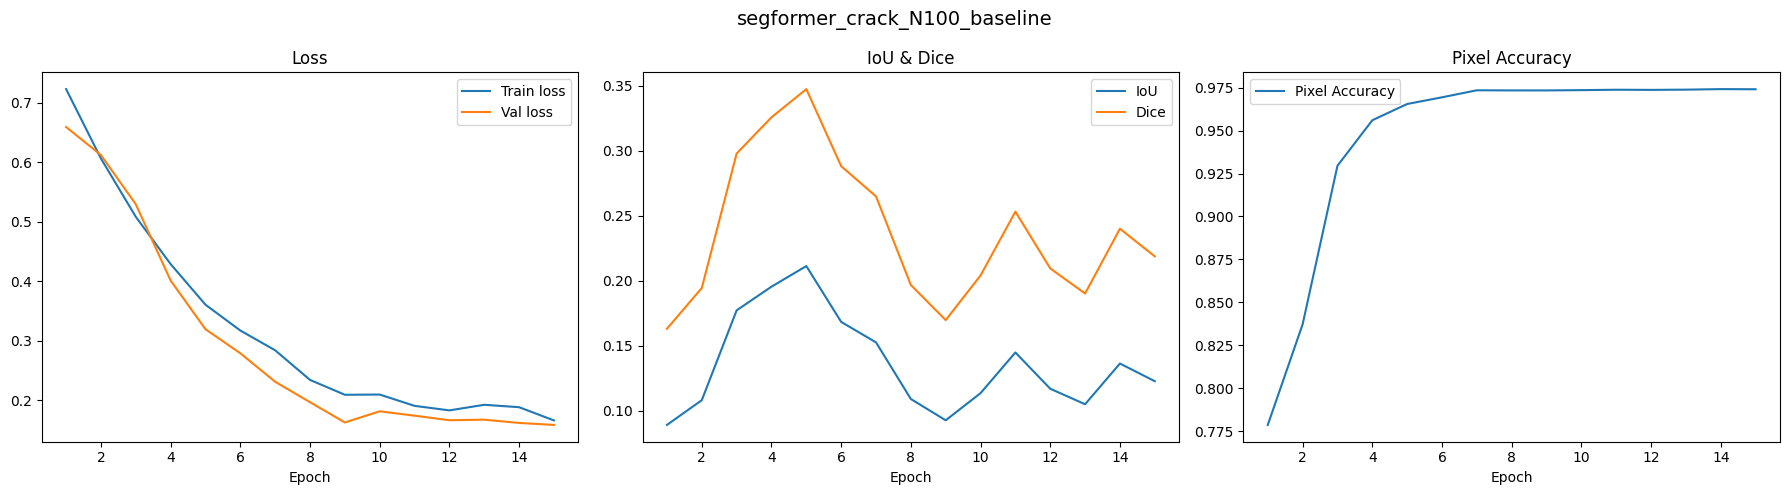

Courbes sauvegardées : /content/drive/MyDrive/segformer_results/segformer_crack_N100_baseline/training_curves.png


Test evaluation: 100%|██████████| 38/38 [00:04<00:00,  8.99it/s]



===== TEST RESULTS — SEGFORMER =====
test_iou: 0.0884
test_dice: 0.1573
test_acc: 0.9383
test_precision: 0.6340
test_recall: 0.0939


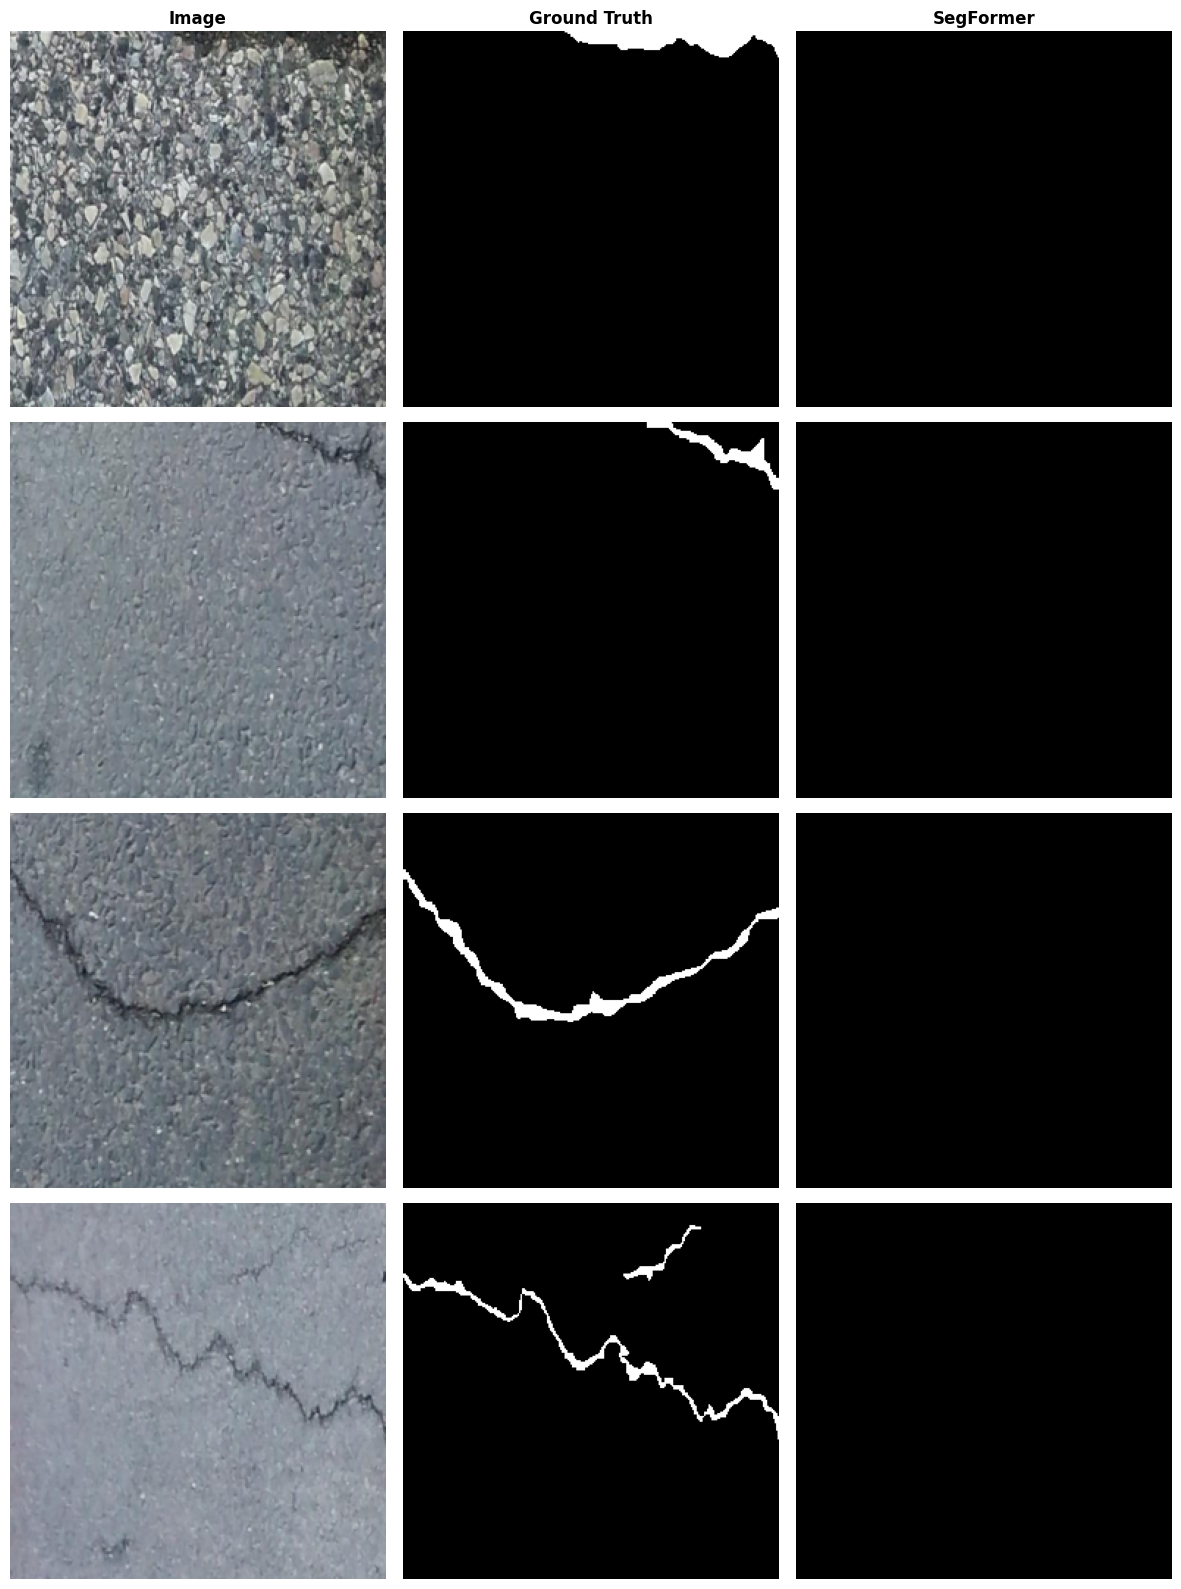

Visualisation sauvegardée : /content/drive/MyDrive/segformer_results/segformer_crack_N100_baseline/qualitative_segformer.png


{'model': 'SegFormer',
 'dataset': 'crack',
 'train_size': 100,
 'augmentation': 'baseline',
 'best_val_iou': 0.21132952719926834,
 'test_iou': 0.0884168958021267,
 'test_dice': 0.1572854958026805,
 'test_acc': 0.9383453569914165,
 'test_precision': 0.6339966961360519,
 'test_recall': 0.09390690663922406}

In [19]:
single_result = train_one_experiment(
    dataset_name="crack",
    train_size=100,
    augmentation_config="baseline"
)

single_result

**LANCEMENT FINAL — EXPÉRIENCES TAILLE DATASET**

✅ SKIP segformer_isic_N50_baseline (déjà terminé)
✅ SKIP segformer_isic_N100_baseline (déjà terminé)
✅ SKIP segformer_isic_N250_baseline (déjà terminé)
✅ SKIP segformer_isic_N500_baseline (déjà terminé)
✅ SKIP segformer_pets_N50_baseline (déjà terminé)
✅ SKIP segformer_pets_N100_baseline (déjà terminé)
✅ SKIP segformer_pets_N250_baseline (déjà terminé)
✅ SKIP segformer_pets_N500_baseline (déjà terminé)
✅ SKIP segformer_crack_N50_baseline (déjà terminé)
✅ SKIP segformer_crack_N100_baseline (déjà terminé)
✅ SKIP segformer_crack_N250_baseline (déjà terminé)

 RUN segformer_crack_N500_baseline
Dataset: crack
Augmentation: baseline
Train size requested: 500
Train: 425 | Val: 75 | Test: 300


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

...


[segformer_crack_N500_baseline] Epoch 18/20
  Train loss : 0.0497
  Val loss   : 0.0805
  Val IoU    : 0.6058   best=0.6158
  Val Dice   : 0.7514
  Val Acc    : 0.9683
  LR         : 5.00e-05
  Patience   : 5/10


[segformer_crack_N500_baseline] Epoch 19 train: 100%|██████████| 54/54 [03:20<00:00,  3.71s/it]



[segformer_crack_N500_baseline] Epoch 19/20
  Train loss : 0.0486
  Val loss   : 0.0802
  Val IoU    : 0.6084   best=0.6158
  Val Dice   : 0.7539
  Val Acc    : 0.9692
  LR         : 5.00e-05
  Patience   : 6/10


[segformer_crack_N500_baseline] Epoch 20 train: 100%|██████████| 54/54 [03:18<00:00,  3.68s/it]



[segformer_crack_N500_baseline] Epoch 20/20
  Train loss : 0.0475
  Val loss   : 0.0802
  Val IoU    : 0.6008   best=0.6158
  Val Dice   : 0.7484
  Val Acc    : 0.9695
  LR         : 5.00e-05
  Patience   : 7/10


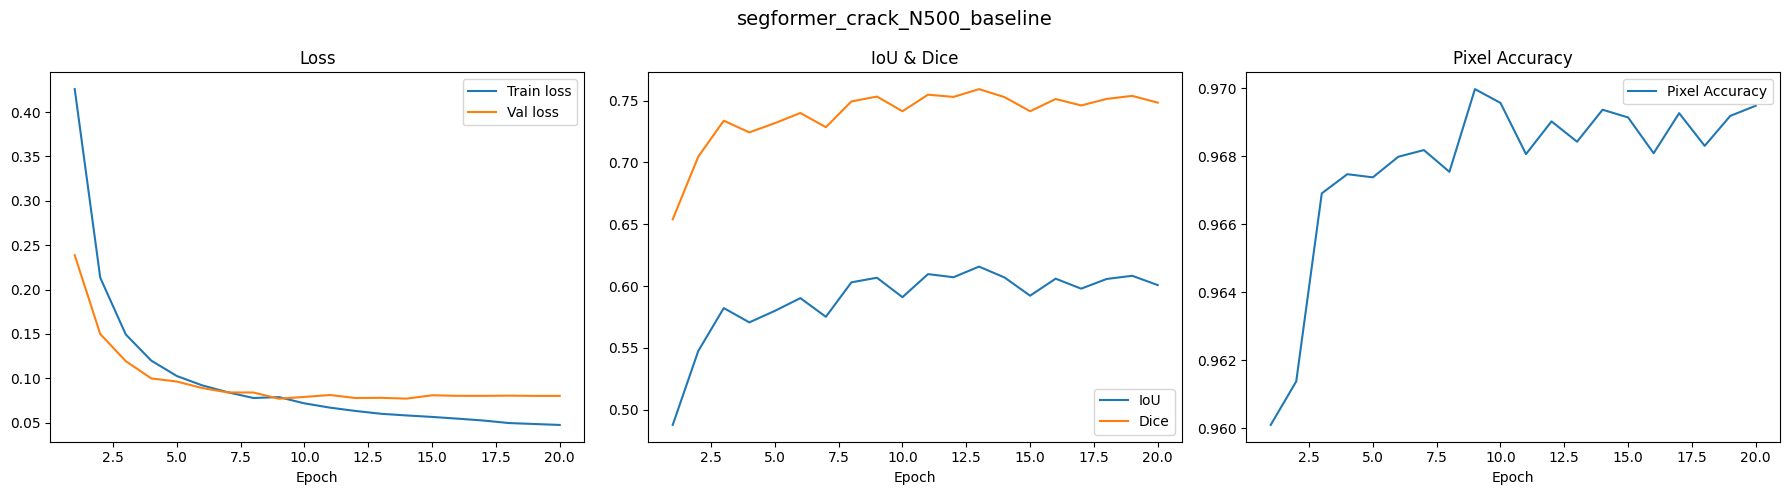

Courbes sauvegardées : /content/drive/MyDrive/segformer_results/segformer_crack_N500_baseline/training_curves.png


Test evaluation: 100%|██████████| 38/38 [00:37<00:00,  1.02it/s]



===== TEST RESULTS — SEGFORMER =====
test_iou: 0.5998
test_dice: 0.7445
test_acc: 0.9698
test_precision: 0.7770
test_recall: 0.7321


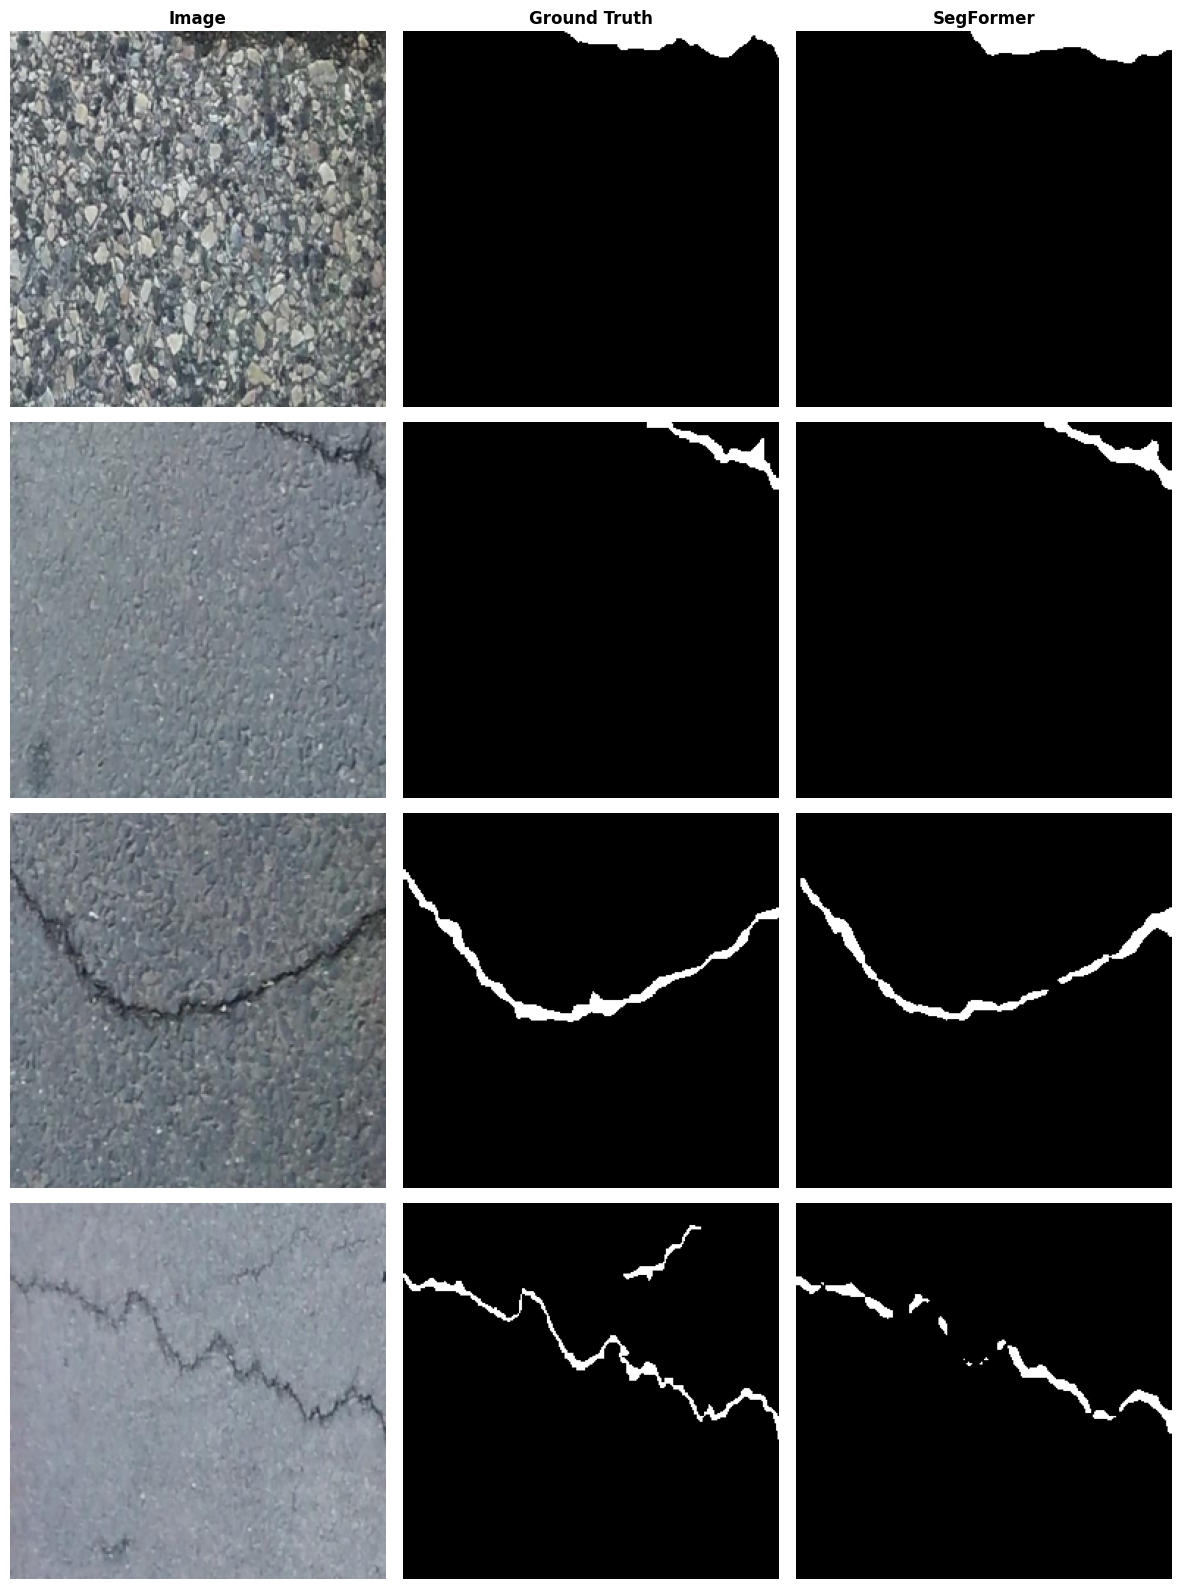

Visualisation sauvegardée : /content/drive/MyDrive/segformer_results/segformer_crack_N500_baseline/qualitative_segformer.png


,model,dataset,train_size,augmentation,test_iou,test_dice,test_acc,test_precision,test_recall,best_val_iou
0,SegFormer,isic,50,baseline,0.703692,0.817261,0.919791,0.912346,0.754524,NaN
1,SegFormer,isic,100,baseline,0.793315,0.879429,0.945274,0.897237,0.873751,NaN
2,SegFormer,isic,250,baseline,0.800826,0.883985,0.947871,0.904948,0.874700,NaN
3,SegFormer,isic,500,baseline,0.855994,0.920981,0.959094,0.939656,0.906191,NaN
4,SegFormer,pets,50,baseline,0.702937,0.823673,0.893879,0.804805,0.852259,NaN
5,SegFormer,pets,100,baseline,0.786206,0.878605,0.929054,0.865123,0.896615,NaN
6,SegFormer,pets,250,baseline,0.816655,0.897559,0.941876,0.898098,0.900138,NaN
7,SegFormer,pets,500,baseline,0.834597,0.908517,0.946880,0.897705,0.921655,NaN
8,SegFormer,crack,50,baseline,0.093269,0.162208,0.940517,0.839082,0.096088,NaN
9,SegFormer,crack,100,baseline,0.464598,0.623486,0.963193,0.859206,0.510851,NaN


In [ ]:
df_size = run_size_experiments()
df_size

**LANCEMENT FINAL — EXPÉRIENCES AUGMENTATION**

In [ ]:
df_aug = run_augmentation_experiments()
df_aug

**EXPORT FINAL**

In [ ]:
print("Résultats sauvegardés dans :", OUTPUT_DIR)

!ls -R /content/segformer_results

Dataset: crack
Augmentation: baseline
Train size requested: 100
Train: 85 | Val: 15 | Test: 300
Indices utilisés : [ 11  12  14 103 150 201]


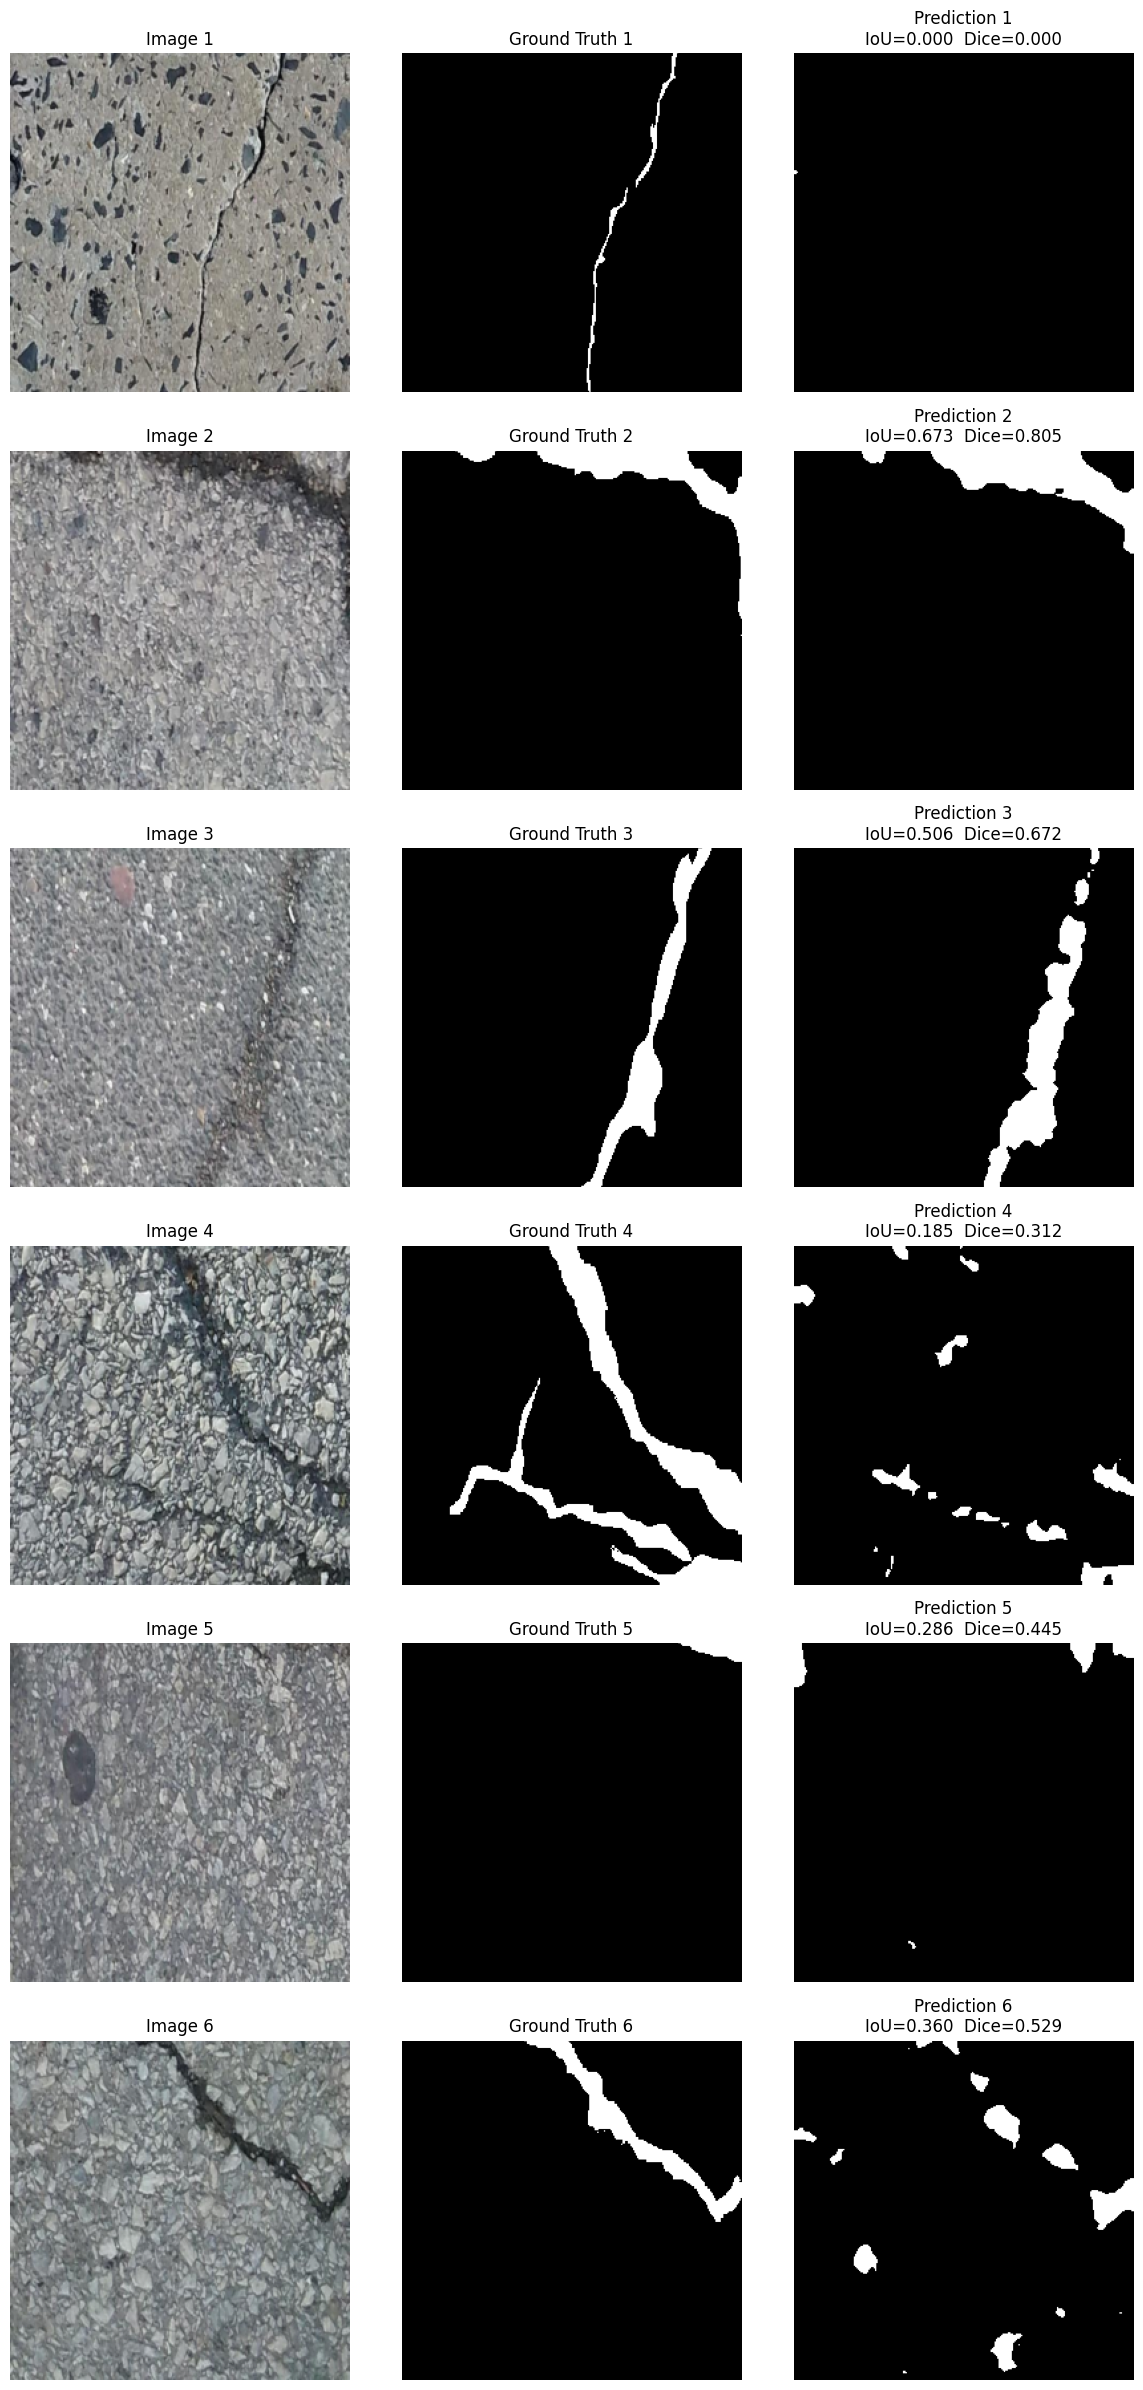

Prédictions sauvegardées : /content/drive/MyDrive/segformer_results/segformer_crack_N100_baseline/predictions_segformer_6_examples.png


In [16]:
########################################
# VISUALISATION QUALITATIVE SEGFORMER (6 exemples)
# Même logique que le code du coéquipier
########################################

# À ajuster selon l'expérience que tu veux visualiser
VIS_DATASET = "crack"
VIS_TRAIN_SIZE = 100
VIS_AUGMENTATION = "baseline"

# Si ton coéquipier te donne ses indices, remplace par exemple :
# COMMON_INDICES = np.array([12, 45, 88, 103, 150, 201])
COMMON_INDICES = np.array([11, 12, 14, 103, 150, 201])

def denormalize(tensor, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    t = tensor.clone()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1)

# Reconstruire le test_dataset exactement comme dans ton pipeline
_, _, test_loader, _, _, test_dataset = build_dataloaders(
    dataset_name=VIS_DATASET,
    train_size=VIS_TRAIN_SIZE,
    augmentation_config=VIS_AUGMENTATION,
    batch_size=BATCH_SIZE
)

# Recharger le meilleur modèle de cette expérience
exp_name = f"segformer_{VIS_DATASET}_N{VIS_TRAIN_SIZE}_{VIS_AUGMENTATION}"
exp_dir = os.path.join(OUTPUT_DIR, exp_name)
best_model_path = os.path.join(exp_dir, "best_segformer.pth")

model_segformer = build_segformer_model()
model_segformer.load_state_dict(torch.load(best_model_path, map_location=device))
model_segformer.to(device)
model_segformer.eval()

num_samples = 6

# Même logique que le coéquipier
if COMMON_INDICES is None:
    np.random.seed(42)
    indices = np.random.choice(len(test_dataset), num_samples, replace=False)
else:
    indices = COMMON_INDICES

print("Indices utilisés :", indices)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

for i, idx in enumerate(indices):

    image, mask = test_dataset[idx]
    image_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model_segformer(pixel_values=image_tensor)
        logits = outputs.logits

        logits = F.interpolate(
            logits,
            size=mask.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        pred_bin = torch.argmax(logits, dim=1).squeeze(0).cpu()

    image_display = denormalize(image).permute(1, 2, 0).cpu()

    iou_val = iou_score_segformer(pred_bin, mask).item()
    dice_val = dice_score_segformer(pred_bin, mask).item()

    axes[i, 0].imshow(image_display)
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask.squeeze(), cmap="gray")
    axes[i, 1].set_title(f"Ground Truth {i+1}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_bin, cmap="gray")
    axes[i, 2].set_title(f"Prediction {i+1}\nIoU={iou_val:.3f}  Dice={dice_val:.3f}")
    axes[i, 2].axis("off")

plt.tight_layout()

save_path = os.path.join(exp_dir, "predictions_segformer_6_examples.png")
plt.savefig(save_path, dpi=150)
plt.show()

print("Prédictions sauvegardées :", save_path)